In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [37]:
pd.set_option('display.max_columns', None)

In [38]:
df = pd.read_csv('../data/gurgaon_properties_missing_value_imputation.csv')

In [39]:
latlong = pd.read_csv('../data/latlong.csv')

In [40]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [41]:
new_df = df.merge(latlong, on='sector')

In [42]:
group_df = (
    new_df
    .groupby('sector', as_index=False)[
        ['price', 'price_per_sqft', 'built_up_area', 'latitude', 'longitude']
    ]
    .mean()
)

In [43]:
group_df

,sector,price,price_per_sqft,built_up_area,latitude,longitude
0,manesar,1.062500,6701.000000,1878.600000,28.3515,76.9428
1,sector 1,1.860000,8249.500000,2328.166667,28.3663,76.9456
2,sector 102,1.681327,10640.946903,1545.787611,28.4750,76.9715
3,sector 103,1.430408,7426.979592,1771.816327,28.4949,76.9845
4,sector 104,1.621159,8926.971014,1808.173913,28.4788,76.9960
...,...,...,...,...,...,...
102,sector 92,0.940571,5934.209524,1578.639810,28.4079,76.9153
103,sector 93,0.808182,8517.363636,941.272727,28.4153,76.9326
104,sector 95,0.494314,5306.215686,1068.784314,28.4172,76.9081
105,sector 99,1.695625,7163.000000,1998.437500,28.4640,76.9614


In [44]:
group_df.head()

,sector,price,price_per_sqft,built_up_area,latitude,longitude
0,manesar,1.062500,6701.000000,1878.600000,28.3515,76.9428
1,sector 1,1.860000,8249.500000,2328.166667,28.3663,76.9456
2,sector 102,1.681327,10640.946903,1545.787611,28.4750,76.9715
3,sector 103,1.430408,7426.979592,1771.816327,28.4949,76.9845
4,sector 104,1.621159,8926.971014,1808.173913,28.4788,76.9960


In [45]:
import folium
from branca.colormap import LinearColormap

# Center of Gurgaon
center_lat = group_df['latitude'].mean()
center_lon = group_df['longitude'].mean()

# Create map
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12
)

# Create color scale based on price per sqft
colormap = LinearColormap(
    colors=['blue', 'green', 'yellow', 'red'],
    vmin=group_df['price_per_sqft'].min(),
    vmax=group_df['price_per_sqft'].max(),
    caption='Average Price per Sqft'
)

# Add sectors
for _, row in group_df.iterrows():

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,
        popup=f"""
        <b>{row['sector']}</b><br>
        Price: ₹{row['price']:.2f} Cr<br>
        Price/sqft: ₹{row['price_per_sqft']:.0f}<br>
        Built-up Area: {row['built_up_area']:.0f} sqft
        """,
        color=colormap(row['price_per_sqft']),
        fill=True,
        fill_color=colormap(row['price_per_sqft']),
        fill_opacity=0.8
    ).add_to(m)

# Add color legend
colormap.add_to(m)



In [48]:
new_df.to_csv('/home/keerthi-180205/Documents/ML_Project1/notebook/data-viz1.csv', index = False)

In [47]:
import os

print(os.getcwd())

/home/keerthi-180205/Documents/ML_Project1/notebook


In [52]:
df1 = pd.read_csv('../data/gurgoan_properties.csv')

In [53]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [54]:
wordcloud_df.head()

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 79
1,"['Power Back-up', 'Feng Shui / Vaastu Complian...",sector 70
2,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'S...",sector 53
3,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 92
4,"['Security / Fire Alarm', 'Lift(s)', 'Maintena...",sector 71


In [55]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [56]:
main

['Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'Swimming Pool',
 'Park',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Water softening plant',
 'Feng Shui / Vaastu Compliant',
 'Lift(s)',
 'Swimming Pool',
 'Internet/wi-fi connectivity',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Security / Fire Alarm',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'I

In [59]:
from wordcloud import WordCloud

In [60]:
feature_text = ' '.join(main)

In [61]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

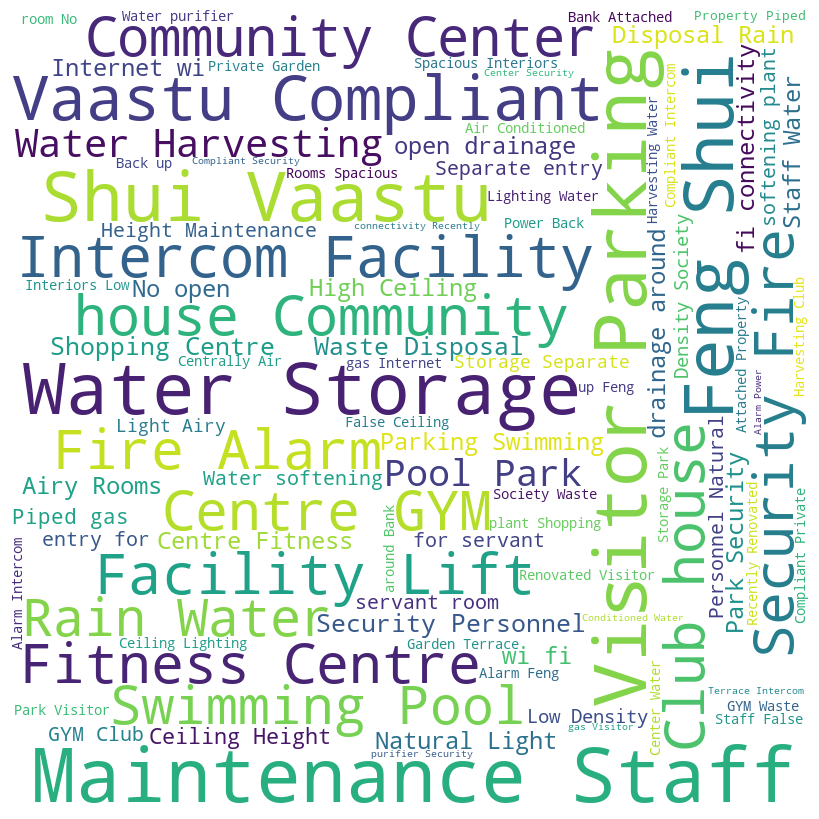

In [63]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [70]:
!pip install streamlit

In [72]:
import streamlit as st

In [73]:
fig = px.scatter(
    df,
    x="built_up_area",
    y="price",
    color="bedRoom",
    title="Area Vs Price"
)

st.plotly_chart(fig, use_container_width=True)

2026-08-28 23:03:13.173 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-28 23:03:13.176 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 23:03:13.176 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 23:03:13.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 23:03:13.232 
  command:

    streamlit run /home/keerthi-180205/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-08-28 23:03:13.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-28 23:03:13.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when

DeltaGenerator()

In [74]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

Opening in existing browser session.
